## Import Library

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool

In [6]:
pd.set_option("display.max_columns", None)

In [7]:
path = r"/Users/tszfungsiu/Desktop/SideProject/customer_churn"

train = pd.read_csv(os.path.join(path, "train.csv"))
test = pd.read_csv(os.path.join(path, "test.csv"))

In [8]:
train.shape

# Check data type
train.info()

# Check null columns
train.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  str    
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  str    
 4   Dependents        594194 non-null  str    
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  str    
 7   MultipleLines     594194 non-null  str    
 8   InternetService   594194 non-null  str    
 9   OnlineSecurity    594194 non-null  str    
 10  OnlineBackup      594194 non-null  str    
 11  DeviceProtection  594194 non-null  str    
 12  TechSupport       594194 non-null  str    
 13  StreamingTV       594194 non-null  str    
 14  StreamingMovies   594194 non-null  str    
 15  Contract          594194 non-null  str    
 16  PaperlessBilling  594194 non-nu

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## EDA

/var/folders/3g/c8lndb_d4vqgxxgs40x419wc0000gn/T/ipykernel_97952/799654809.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Churn')
/var/folders/3g/c8lndb_d4vqgxxgs40x419wc0000gn/T/ipykernel_97952/799654809.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Churn')
/var/folders/3g/c8lndb_d4vqgxxgs40x419wc0000gn/T/ipykernel_97952/799654809.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Churn')
/var/folders/3g/c8lndb_d4vqgxxgs40x419wc0000gn/T/ipykernel_97952/799654809.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists

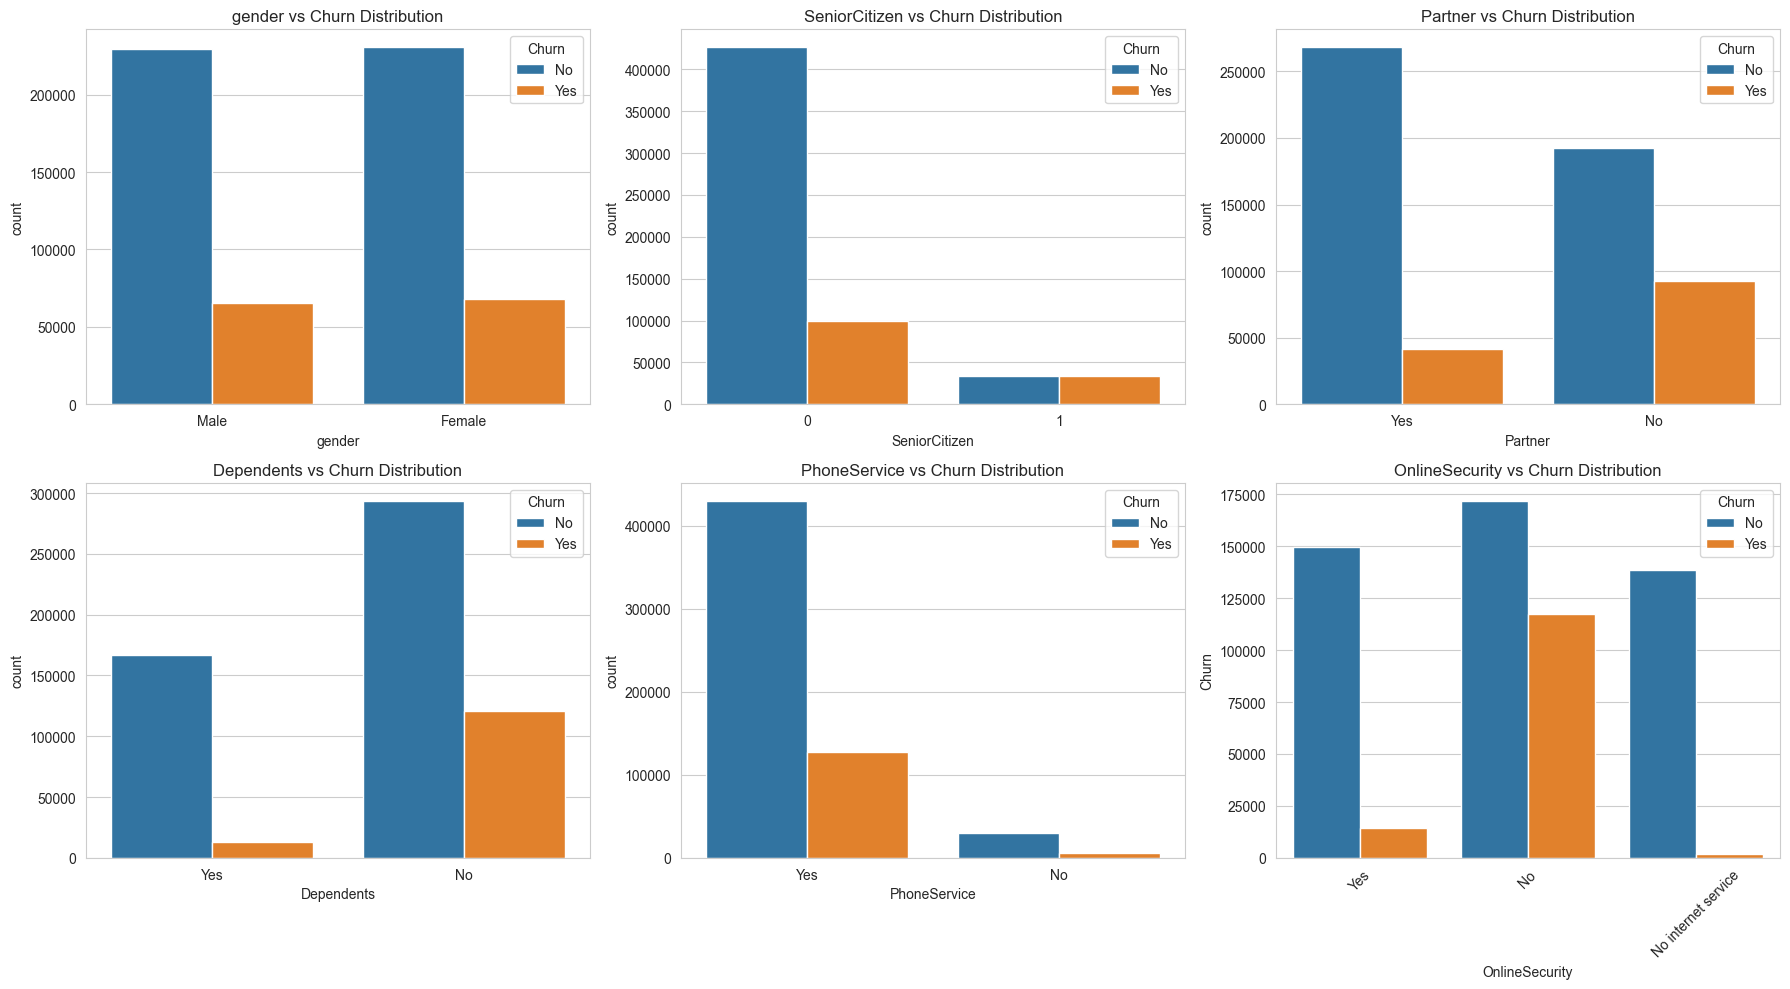

In [9]:
# Bar Plot on gender, SeniorCitizen, Partner, Dependents, PhoneService, OnlineSecurity
plt.rcParams["figure.figsize"] = (15, 8)
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'OnlineSecurity']

for i, feature in enumerate(features):
    ax = sns.countplot(train[['Churn', feature]], x=f"{feature}", hue='Churn', ax=axes[i])
    ax.set_title(f"{feature} vs Churn Distribution")
    plt.ylabel('Churn')
    plt.xticks(rotation=45)
    plt.legend(title='Churn')
    
plt.tight_layout()
plt.show()

/var/folders/3g/c8lndb_d4vqgxxgs40x419wc0000gn/T/ipykernel_97952/972671175.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Churn')
/var/folders/3g/c8lndb_d4vqgxxgs40x419wc0000gn/T/ipykernel_97952/972671175.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Churn')
/var/folders/3g/c8lndb_d4vqgxxgs40x419wc0000gn/T/ipykernel_97952/972671175.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Churn')
/var/folders/3g/c8lndb_d4vqgxxgs40x419wc0000gn/T/ipykernel_97952/972671175.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists

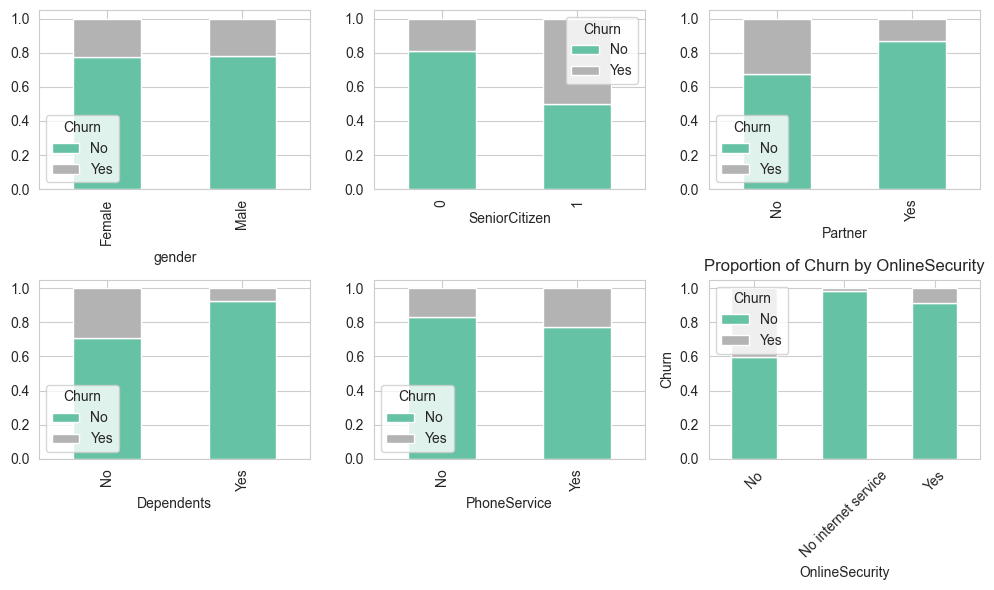

In [10]:
# Stacked Bar Chart on gender, SeniorCitizen, Partner, Dependents, PhoneService, OnlineSecurity
plt.rcParams["figure.figsize"] = (15, 8)
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'OnlineSecurity']

for i, feature in enumerate(features):
    ct = pd.crosstab(train[feature], train['Churn'], normalize='index')
    ct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2', ax=axes[i])
    plt.title(f"Proportion of Churn by {feature}")
    plt.ylabel('Churn')
    plt.xticks(rotation=45)
    plt.legend(title='Churn')
    
plt.tight_layout()
plt.show()

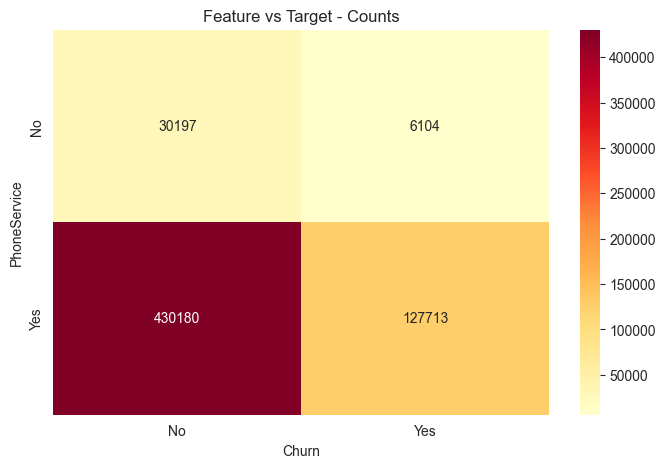

In [11]:
# cross tabulation heatmap
ct = pd.crosstab(train['PhoneService'], train['Churn'])

plt.figure(figsize=(8, 5))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Feature vs Target - Counts')
plt.show()

In [12]:
# chi-square
features = [i for i in train.columns if i not in ["Churn"]]
for feature in features:
    ct = pd.crosstab(train[feature], train['Churn'])
    chi2, p_value, dof, expected = chi2_contingency(ct)
    print(f"{feature:25s} | Chi2: {chi2:10.2f} | p-value: {p_value:.6f} | {'Significant ✅' if p_value < 0.05 else 'Not Significant ❌'}")

id                        | Chi2:  594194.00 | p-value: 0.499390 | Not Significant ❌
gender                    | Chi2:      27.51 | p-value: 0.000000 | Significant ✅
SeniorCitizen             | Chi2:   33193.98 | p-value: 0.000000 | Significant ✅
Partner                   | Chi2:   30944.98 | p-value: 0.000000 | Significant ✅
Dependents                | Chi2:   34329.59 | p-value: 0.000000 | Significant ✅
tenure                    | Chi2:  119835.61 | p-value: 0.000000 | Significant ✅
PhoneService              | Chi2:     721.02 | p-value: 0.000000 | Significant ✅
MultipleLines             | Chi2:    7888.57 | p-value: 0.000000 | Significant ✅
InternetService           | Chi2:  107801.94 | p-value: 0.000000 | Significant ✅
OnlineSecurity            | Chi2:  108175.34 | p-value: 0.000000 | Significant ✅
OnlineBackup              | Chi2:   79195.70 | p-value: 0.000000 | Significant ✅
DeviceProtection          | Chi2:   72256.07 | p-value: 0.000000 | Significant ✅
TechSupport             

## Encode Categorical Variables

In [13]:
le = LabelEncoder()

cat_features = [col for col in train.columns if isinstance(train[col].iloc[0], str)]

for col in cat_features:
    train[col] = le.fit_transform(train[col])

## Define features and target

In [14]:
X = train.drop(['Churn', 'id'], axis=1)
y = train['Churn']

# Train Test Split
X_train, x_train_test, y_train, y_train_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
models = {
    "Random Forest Classifier": RandomForestClassifier(
                        n_estimators=100,
                        random_state=42
                    ),
    "CatBoost Classifier": CatBoostClassifier(
                        iterations=100,
                        learning_rate=0.1,
                        depth=6,
                        loss_function='MultiClass',
                        verbose=0
                    )
}

In [20]:
y_pred_random_forest = None
y_pred_catboost = None

for name, model in models.items():

    model.fit(X_train, y_train)
    
    predictions = model.predict(x_train_test)
    
    # Get probabilities for AUC-ROC
    y_proba = model.predict_proba(x_train_test)[:, 1]

    if name == "Random Forest Classifier":
        class_report = classification_report(y_train_test, predictions, target_names=['0','1'])
        random_forest_classification_report = class_report
        y_pred_random_forest = y_proba

    else:
        class_report = classification_report(y_train_test, predictions, target_names=['0','1'])
        catboost_classification_report = class_report
        y_pred_catboost = y_proba

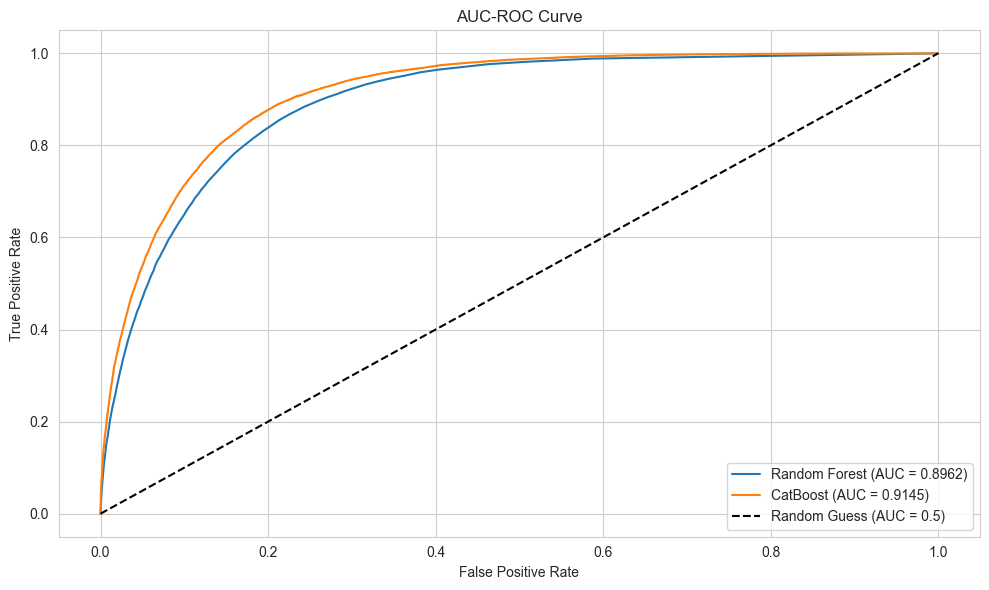

In [25]:
# AUC score
auc_random_forest = roc_auc_score(y_train_test, y_pred_random_forest)
auc_catboost = roc_auc_score(y_train_test, y_pred_catboost)

# ROC curve
fpr_random_forest, tpr_random_forest, thresholds_random_forest = roc_curve(y_train_test, y_pred_random_forest)
fpr_catboost, tpr_catboost, thresholds_catboost = roc_curve(y_train_test, y_pred_catboost)

plt.figure(figsize=(10, 6))

plt.plot(fpr_random_forest, tpr_random_forest, label=f"Random Forest (AUC = {auc_random_forest:.4f})")
plt.plot(fpr_catboost, tpr_catboost, label=f"CatBoost (AUC = {auc_catboost:.4f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess (AUC = 0.5)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [17]:
print(random_forest_classification_report)
print(catboost_classification_report)

              precision    recall  f1-score   support

           0       0.89      0.92      0.90     91935
           1       0.68      0.60      0.64     26904

    accuracy                           0.85    118839
   macro avg       0.78      0.76      0.77    118839
weighted avg       0.84      0.85      0.84    118839

              precision    recall  f1-score   support

           0       0.90      0.92      0.91     91935
           1       0.71      0.64      0.67     26904

    accuracy                           0.86    118839
   macro avg       0.80      0.78      0.79    118839
weighted avg       0.86      0.86      0.86    118839

